# Splitting an Object into Groups

In [2]:
import pandas as pd
import numpy as np

In [3]:
speeds = pd.DataFrame(
    [
        ("bird", "Falconiformes", 389.0),
        ("bird", "Psittaciformes", 24.0),
        ("mammal", "Carnivora", 80.2),
        ("mammal", "Primates", np.nan),
        ("mammal", "Carnivora", 58),
    ],
    index=["falcon", "parrot", "lion", "monkey", "leopard"],
    columns=["class", "order", "max_speed"],
)

In [4]:
speeds

,class,order,max_speed
falcon,bird,Falconiformes,389.0
parrot,bird,Psittaciformes,24.0
lion,mammal,Carnivora,80.2
monkey,mammal,Primates,NaN
leopard,mammal,Carnivora,58.0


In [5]:
grouped = speeds.groupby("class")
grouped = speeds.groupby(["class", "order"])

In [6]:
df = pd.DataFrame(
    {
        "A": ["foo", "bar", "foo", "bar", "foo", "bar", "foo", "foo"],
        "B": ["one", "one", "two", "three", "two", "two", "one", "three"],
        "C": np.random.randn(8),
        "D": np.random.randn(8),
    }
)

In [7]:
df

,A,B,C,D
0,foo,one,2.273353,2.151476
1,bar,one,-0.311118,0.341885
2,foo,two,-1.196094,1.161944
3,bar,three,-0.806405,0.479349
4,foo,two,1.195541,0.302438
5,bar,two,-3.393476,-0.008960
6,foo,one,1.431147,-0.619764
7,foo,three,1.333645,1.157188


In [8]:
grouped = df.groupby("A")  # group by column "A"
grouped = df.groupby("B")  # group by column "B"
grouped = df.groupby(["A", "B"])  # group by both columns

DataFrame groupby always operates along axis 0 (rows).<br/>
To split by columns, first do a transpose:

In [9]:
def get_letter_type(letter):
    if letter.lower() in "aeiou":
        return "vowel"
    else:
        return "consonant"


grouped = df.T.groupby(get_letter_type)

In [10]:
# A Series with an Index with duplicate values.
# If we group by this Index of non-unique values, all Series values with the same Index
# will be considered to be in the same group.
index = [1, 2, 3, 1, 2, 3]
s = pd.Series([1, 2, 3, 10, 20, 30], index=index)
s

1     1
2     2
3     3
1    10
2    20
3    30
dtype: int64

In [11]:
grouped = s.groupby(level=0)

In [12]:
grouped.first()

1    1
2    2
3    3
dtype: int64

In [13]:
grouped.last()

1    10
2    20
3    30
dtype: int64

In [14]:
# When aggregating, the splitting occurs correctly
grouped.sum()

1    11
2    22
3    33
dtype: int64

## GroupBy Sorting

The group keys are sorted by default. With `sort=False`, no sorting occurs and the keys follow
the order of appearance. Use this for potential speedups.

In [15]:
df2 = pd.DataFrame({"X": ["B", "B", "A", "A"], "Y": [1, 2, 3, 4]})
df2.groupby(["X"]).sum()  # key "A" appears before key "B"

,Y
X,
A,7
B,3


In [16]:
df2 = pd.DataFrame({"X": ["B", "B", "A", "A"], "Y": [1, 2, 3, 4]})
df2.groupby(["X"], sort=False).sum()  # key "B" appears first in the DataFrame

,Y
X,
B,3
A,7


### GroupBy dropna
NA values are by default excluded from group keys. To include them use `dropna=False`

In [17]:
df_list = [
    [1, 2, 3],
    [1, None, 4],
    [2, 1, 3],
    [1, 2, 2],
]

df_dropna = pd.DataFrame(df_list, columns=["a", "b", "c"])
df_dropna

,a,b,c
0,1,2.0,3
1,1,NaN,4
2,2,1.0,3
3,1,2.0,2


In [18]:
# Default ``dropna`` is set to True, which will exclude NaNs in keys
df_dropna.groupby(by=["b"], dropna=True).sum()

,a,c
b,,
1.0,2,3
2.0,2,5


In [19]:
# In order to allow Nans in keys, set dropna to False
df_dropna.groupby(by=["b"], dropna=False).sum()

,a,c
b,,
1.0,2,3
2.0,2,5
NaN,1,4


## GroupBy Object Attributes
`GroupBy.groups` returns a dictionary of the form:

> **key**   : a unique group key<br/>
> **value** : a list of index labels belonging to that group

In [20]:
df.groupby("A").groups

{'bar': [1, 3, 5], 'foo': [0, 2, 4, 6, 7]}

In [21]:
df.T.groupby(get_letter_type).groups

{'consonant': ['B', 'C', 'D'], 'vowel': ['A']}

In [22]:
grouped = df.groupby(["A", "B"])
grouped.groups

{('bar', 'one'): RangeIndex(start=1, stop=2, step=1),
 ('bar', 'three'): RangeIndex(start=3, stop=4, step=1),
 ('bar', 'two'): RangeIndex(start=5, stop=6, step=1),
 ('foo', 'one'): RangeIndex(start=0, stop=12, step=6),
 ('foo', 'three'): RangeIndex(start=7, stop=8, step=1),
 ('foo', 'two'): RangeIndex(start=2, stop=6, step=2)}

In [23]:
# len(GroupBy) returns the number of groups created
len(grouped)

6

In [24]:
n = 10
weight = np.random.normal(166, 20, size=n)
height = np.random.normal(60, 10, size=n)
time = pd.date_range("1/1/2000", periods=n)
gender = np.random.choice(["male", "female"], size=n)

df = pd.DataFrame(
    {
        "height": height,
        "weight": weight,
        "gender": gender,
    },
    index=time,
)

In [25]:
df

,height,weight,gender
2000-01-01,70.029767,156.425336,male
2000-01-02,54.708636,169.406299,female
2000-01-03,41.618445,170.787251,female
2000-01-04,56.192302,203.935773,male
2000-01-05,55.030506,153.746400,female
2000-01-06,47.062588,185.614406,female
2000-01-07,64.566051,165.436366,male
2000-01-08,68.667873,152.980704,male
2000-01-09,61.974067,160.822042,male
2000-01-10,57.077915,172.946298,female


In [26]:
gb = df.groupby("gender")

## GroupBy with MultiIndex

In [27]:
arrays = [
    ["bar", "bar", "baz", "baz", "foo", "foo", "qux", "qux"],
    ["one", "two", "one", "two", "one", "two", "one", "two"],
]

# A hierarchical two-level MultiIndex
index = pd.MultiIndex.from_arrays(arrays, names=["first", "second"])

# A Series with a two-level MultiIndex
s = pd.Series(np.random.randn(8), index=index)
s

first  second
bar    one      -0.120748
       two       0.100913
baz    one       0.110346
       two       1.441055
foo    one       1.250123
       two       2.424369
qux    one       1.216404
       two      -0.681943
dtype: float64

In [28]:
# Group by the first level in s
grouped = s.groupby(level=0)
grouped.sum()

first
bar   -0.019835
baz    1.551401
foo    3.674492
qux    0.534461
dtype: float64

In [29]:
# Use the name of the level instead of the level number
s.groupby(level="second").sum()

second
one    2.456125
two    3.284394
dtype: float64

In [30]:
# Grouping with multiple levels
arrays = [
    ["bar", "bar", "baz", "baz", "foo", "foo", "qux", "qux"],
    ["doo", "doo", "bee", "bee", "bop", "bop", "bop", "bop"],
    ["one", "two", "one", "two", "one", "two", "one", "two"],
]

index = pd.MultiIndex.from_arrays(arrays, names=["first", "second", "third"])
s = pd.Series(np.random.randn(8), index=index)
s

first  second  third
bar    doo     one      0.410831
               two      0.116573
baz    bee     one     -0.526952
               two     -0.781856
foo    bop     one      0.222353
               two     -1.436750
qux    bop     one      1.108931
               two     -2.615807
dtype: float64

In [31]:
s.groupby(level=["first", "second"]).sum()

first  second
bar    doo       0.527404
baz    bee      -1.308808
foo    bop      -1.214397
qux    bop      -1.506875
dtype: float64

## Grouping DataFrame with Index Levels and Columns
To groupby a combination of columns and index levels use a `Grouper`

In [32]:
arrays = [
    ["bar", "bar", "baz", "baz", "foo", "foo", "qux", "qux"],
    ["one", "two", "one", "two", "one", "two", "one", "two"],
]

# A hierarchical two-level MultiIndex
index = pd.MultiIndex.from_arrays(arrays, names=["first", "second"])

df = pd.DataFrame(
    {"A": [1, 1, 1, 1, 2, 2, 3, 3], "B": np.arange(8)},
    index=index,
)

df

A  B
first second      
bar   one     1  0
      two     1  1
baz   one     1  2
      two     1  3
foo   one     2  4
      two     2  5
qux   one     3  6
      two     3  7

In [33]:
# Group by the second index level and column A:
df.groupby([pd.Grouper(level=1), "A"]).sum()

B
second A   
one    1  2
       2  4
       3  6
two    1  4
       2  5
       3  7

In [34]:
# Or without a Grouper:
df.groupby(["second", "A"]).sum()

B
second A   
one    1  2
       2  4
       3  6
two    1  4
       2  5
       3  7

## DataFrame Column Selection in GroupBy

In [35]:
df = pd.DataFrame(
    {
        "A": ["foo", "bar", "foo", "bar", "foo", "bar", "foo", "foo"],
        "B": ["one", "one", "two", "three", "two", "two", "one", "three"],
        "C": np.random.randn(8),
        "D": np.random.randn(8),
    }
)
df

,A,B,C,D
0,foo,one,-0.131856,-0.498288
1,bar,one,-1.231004,-0.290932
2,foo,two,-0.647966,-0.411487
3,bar,three,-1.364391,1.256984
4,foo,two,1.689970,1.068903
5,bar,two,-0.493866,1.551329
6,foo,one,1.414405,0.512014
7,foo,three,-1.096674,0.333688


In [36]:
grouped = df.groupby(by="A")
grouped_C = grouped["C"]
grouped_D = grouped["D"]

# Iterating through Groups

In [37]:
grouped = df.groupby("A")

for name, group in grouped:
    print(name)
    print(group)

bar
     A      B         C         D
1  bar    one -1.231004 -0.290932
3  bar  three -1.364391  1.256984
5  bar    two -0.493866  1.551329
foo
     A      B         C         D
0  foo    one -0.131856 -0.498288
2  foo    two -0.647966 -0.411487
4  foo    two  1.689970  1.068903
6  foo    one  1.414405  0.512014
7  foo  three -1.096674  0.333688


In [38]:
for name, group in df.groupby(["A", "B"]):
    print(name)
    print(group)

('bar', 'one')
     A    B         C         D
1  bar  one -1.231004 -0.290932
('bar', 'three')
     A      B         C         D
3  bar  three -1.364391  1.256984
('bar', 'two')
     A    B         C         D
5  bar  two -0.493866  1.551329
('foo', 'one')
     A    B         C         D
0  foo  one -0.131856 -0.498288
6  foo  one  1.414405  0.512014
('foo', 'three')
     A      B         C         D
7  foo  three -1.096674  0.333688
('foo', 'two')
     A    B         C         D
2  foo  two -0.647966 -0.411487
4  foo  two  1.689970  1.068903


# Selecting a Group

In [39]:
grouped.get_group("bar")

,A,B,C,D
1,bar,one,-1.231004,-0.290932
3,bar,three,-1.364391,1.256984
5,bar,two,-0.493866,1.551329


In [40]:
df.groupby(["A", "B"]).get_group(("bar", "one"))

,A,B,C,D
1,bar,one,-1.231004,-0.290932


# Aggregation

In [41]:
# Sum each column in a group of values
animals = pd.DataFrame(
    {
        "kind": ["cat", "dog", "cat", "dog"],
        "height": [9.1, 6.0, 9.5, 34.0],
        "weight": [7.9, 7.5, 9.9, 198.0],
    }
)
animals

,kind,height,weight
0,cat,9.1,7.9
1,dog,6.0,7.5
2,cat,9.5,9.9
3,dog,34.0,198.0


In [42]:
animals.groupby("kind").sum()

,height,weight
kind,,
cat,18.6,17.8
dog,40.0,205.5


To include the group keys as columns use `as_index=False`

In [43]:
animals.groupby("kind", as_index=False).sum()

,kind,height,weight
0,cat,18.6,17.8
1,dog,40.0,205.5


## Built-in Aggregation Methods
- sum(), prod()
- min(), max()
- var(), std()
- any(), all()
- idxmax(), idxmin()

In [44]:
df.groupby("A")[["C", "D"]].max()

,C,D
A,,
bar,-0.493866,1.551329
foo,1.689970,1.068903


In [45]:
df.groupby(["A", "B"]).mean()

C         D
A   B                        
bar one   -1.231004 -0.290932
    three -1.364391  1.256984
    two   -0.493866  1.551329
foo one    0.641274  0.006863
    three -1.096674  0.333688
    two    0.521002  0.328708

In [46]:
grouped = df.groupby(["A", "B"])
grouped.size()

A    B    
bar  one      1
     three    1
     two      1
foo  one      2
     three    1
     two      2
dtype: int64

In [47]:
# Summary statistics about each of the groups
grouped.describe()

C                                                              \
          count      mean       std       min       25%       50%       75%   
A   B                                                                         
bar one     1.0 -1.231004       NaN -1.231004 -1.231004 -1.231004 -1.231004   
    three   1.0 -1.364391       NaN -1.364391 -1.364391 -1.364391 -1.364391   
    two     1.0 -0.493866       NaN -0.493866 -0.493866 -0.493866 -0.493866   
foo one     2.0  0.641274  1.093372 -0.131856  0.254709  0.641274  1.027840   
    three   1.0 -1.096674       NaN -1.096674 -1.096674 -1.096674 -1.096674   
    two     2.0  0.521002  1.653170 -0.647966 -0.063482  0.521002  1.105486   

                        D                                                    \
                max count      mean       std       min       25%       50%   
A   B                                                                         
bar one   -1.231004   1.0 -0.290932       NaN -0.290932 -0.290932 -0.290932   
    three -1.364391   1.0  1.256984       NaN  1.256984  1.256984  1.256984   
    two   -0.493866   1.0  1.551329       NaN  1.551329  1.551329  1.551329   
foo one    1.414405   2.0  0.006863  0.714391 -0.498288 -0.245713  0.006863   
    three -1.096674   1.0  0.333688       NaN  0.333688  0.333688  0.333688   
    two    1.689970   2.0  0.328708  1.046794 -0.411487 -0.041390  0.328708   

                               
                75%       max  
A   B                          
bar one   -0.290932 -0.290932  
    three  1.256984  1.256984  
    two    1.551329  1.551329  
foo one    0.259438  0.512014  
    three  0.333688  0.333688  
    two    0.698806  1.068903

In [48]:
# Return the number of unique values of each group
ll = [["foo", 1], ["foo", 2], ["foo", 2], ["bar", 1], ["bar", 1]]
df4 = pd.DataFrame(ll, columns=["A", "B"])
df4

,A,B
0,foo,1
1,foo,2
2,foo,2
3,bar,1
4,bar,1


In [49]:
df4.groupby(["A"])["B"].nunique()

A
bar    1
foo    2
Name: B, dtype: int64

## The `aggregate()` method
Pass any supported reduction method, as a string to aggregate()

In [50]:
grouped = df.groupby("A")
grouped[["C", "D"]].aggregate("sum")

,C,D
A,,
bar,-3.089261,2.517381
foo,1.227879,1.004830


In [51]:
# The names of the resulting groups form the new MultiIndex
grouped = df.groupby(["A", "B"])
grouped.agg("sum")

C         D
A   B                        
bar one   -1.231004 -0.290932
    three -1.364391  1.256984
    two   -0.493866  1.551329
foo one    1.282549  0.013726
    three -1.096674  0.333688
    two    1.042004  0.657416

In [52]:
# The names of the resulting groups are included as columns
grouped = df.groupby(["A", "B"], as_index=False)
grouped.agg("sum")

,A,B,C,D
0,bar,one,-1.231004,-0.290932
1,bar,three,-1.364391,1.256984
2,bar,two,-0.493866,1.551329
3,foo,one,1.282549,0.013726
4,foo,three,-1.096674,0.333688
5,foo,two,1.042004,0.657416


## Aggregation with User-Defined Functions

In [53]:
animals

,kind,height,weight
0,cat,9.1,7.9
1,dog,6.0,7.5
2,cat,9.5,9.9
3,dog,34.0,198.0


In [54]:
animals.groupby("kind")[["height"]].agg(lambda x: set(x))

,height
kind,
cat,"{9.1, 9.5}"
dog,"{34.0, 6.0}"


## Applying Multiple Functions at Once

In [55]:
df

,A,B,C,D
0,foo,one,-0.131856,-0.498288
1,bar,one,-1.231004,-0.290932
2,foo,two,-0.647966,-0.411487
3,bar,three,-1.364391,1.256984
4,foo,two,1.689970,1.068903
5,bar,two,-0.493866,1.551329
6,foo,one,1.414405,0.512014
7,foo,three,-1.096674,0.333688


In [56]:
grouped = df.groupby("A")
grouped["C"].agg(["sum", "mean", "std"])

,sum,mean,std
A,,,
bar,-3.089261,-1.029754,0.468860
foo,1.227879,0.245576,1.244482


In [57]:
grouped[["C", "D"]].agg(["sum", "mean", "std"])

C                             D                    
          sum      mean       std       sum      mean       std
A                                                              
bar -3.089261 -1.029754  0.468860  2.517381  0.839127  0.989664
foo  1.227879  0.245576  1.244482  1.004830  0.200966  0.657977

In [58]:
(
    grouped["C"]
    .agg(["sum", "mean", "std"])
    .rename(
        columns={
            "sum": "foo",
            "mean": "bar",
            "std": "baz",
        }
    )
)

,foo,bar,baz
A,,,
bar,-3.089261,-1.029754,0.468860
foo,1.227879,0.245576,1.244482


In [59]:
# Rename a grouped DataFrame
(
    grouped[["C", "D"]]
    .agg(["sum", "mean", "std"])
    .rename(
        columns={
            "sum": "foo",
            "mean": "bar",
            "std": "baz",
        }
    )
)

C                             D                    
          foo       bar       baz       foo       bar       baz
A                                                              
bar -3.089261 -1.029754  0.468860  2.517381  0.839127  0.989664
foo  1.227879  0.245576  1.244482  1.004830  0.200966  0.657977

## Named Aggregation

In [60]:
animals

,kind,height,weight
0,cat,9.1,7.9
1,dog,6.0,7.5
2,cat,9.5,9.9
3,dog,34.0,198.0


In [61]:
animals.groupby("kind").agg(
    min_height=pd.NamedAgg(column="height", aggfunc="min"),
    max_height=pd.NamedAgg(column="height", aggfunc="max"),
    average_weight=pd.NamedAgg(column="weight", aggfunc="mean"),
)

,min_height,max_height,average_weight
kind,,,
cat,9.1,9.5,8.90
dog,6.0,34.0,102.75


## Applying Different Functions to DataFrame Columns

In [62]:
grouped.agg(
    {
        "C": "sum",
        "D": lambda x: np.std(x, ddof=1),
    }
)

,C,D
A,,
bar,-3.089261,0.989664
foo,1.227879,0.657977


# Transformation

In [63]:
speeds

,class,order,max_speed
falcon,bird,Falconiformes,389.0
parrot,bird,Psittaciformes,24.0
lion,mammal,Carnivora,80.2
monkey,mammal,Primates,NaN
leopard,mammal,Carnivora,58.0


In [64]:
grouped = speeds.groupby("class")["max_speed"]
grouped.cumsum()

falcon     389.0
parrot     413.0
lion        80.2
monkey       NaN
leopard    138.2
Name: max_speed, dtype: float64

In [65]:
grouped.diff()

falcon       NaN
parrot    -365.0
lion         NaN
monkey       NaN
leopard      NaN
Name: max_speed, dtype: float64

In [66]:
# Use a transformation to add the result back to the original df
result = speeds.copy()
result["cumsum"] = grouped.cumsum()
result["diff"] = grouped.diff()
result

,class,order,max_speed,cumsum,diff
falcon,bird,Falconiformes,389.0,389.0,NaN
parrot,bird,Psittaciformes,24.0,413.0,-365.0
lion,mammal,Carnivora,80.2,80.2,NaN
monkey,mammal,Primates,NaN,NaN,NaN
leopard,mammal,Carnivora,58.0,138.2,NaN


## Built-in Transformation Methods

**bfill(), cumcount(), cummax(),cummin(), cumprod(), cumsum(), diff(), ffill(), pct_change(), rank(), shift()**

## The `transform()` Method

In [67]:
speeds

,class,order,max_speed
falcon,bird,Falconiformes,389.0
parrot,bird,Psittaciformes,24.0
lion,mammal,Carnivora,80.2
monkey,mammal,Primates,NaN
leopard,mammal,Carnivora,58.0


In [68]:
grouped = speeds.groupby("class")[["max_speed"]]
grouped.transform("cumsum")

,max_speed
falcon,389.0
parrot,413.0
lion,80.2
monkey,NaN
leopard,138.2


In [69]:
grouped.transform("sum")

,max_speed
falcon,413.0
parrot,413.0
lion,138.2
monkey,138.2
leopard,138.2


In [70]:
# Standardize the data within each group:
index = pd.date_range("10/1/1999", periods=1100)
ts = pd.Series(np.random.normal(0.5, 2, 1100), index)
ts = ts.rolling(window=100, min_periods=100).mean().dropna()
ts.head()

2000-01-08    0.601551
2000-01-09    0.613900
2000-01-10    0.606064
2000-01-11    0.612782
2000-01-12    0.598365
Freq: D, dtype: float64

In [71]:
ts.tail()

2002-09-30    0.438873
2002-10-01    0.460619
2002-10-02    0.483603
2002-10-03    0.485592
2002-10-04    0.493776
Freq: D, dtype: float64

In [72]:
# fmt: off
transformed = (
                ts.groupby(lambda x: x.year)
                  .transform(lambda x: (x - x.mean()) / x.std())
            )

**Note** that what we did is actually applying the standardization formula, so we would expect the result to now have mean 0 and SD 1 in each group:

$\Large z=\frac{x-\bar{x}}{s}$

In [73]:
# Original data
grouped = ts.groupby(lambda x: x.year)
grouped.mean()

2000    0.537194
2001    0.724748
2002    0.604999
dtype: float64

In [74]:
grouped.std()

2000    0.101583
2001    0.119659
2002    0.122807
dtype: float64

In [75]:
# Transformed data
grouped_trans = transformed.groupby(lambda x: x.year)
grouped_trans.mean()

2000   -6.692264e-16
2001   -8.498529e-16
2002   -2.356719e-16
dtype: float64

In [76]:
grouped_trans.std()

2000    1.0
2001    1.0
2002    1.0
dtype: float64

<Axes: >

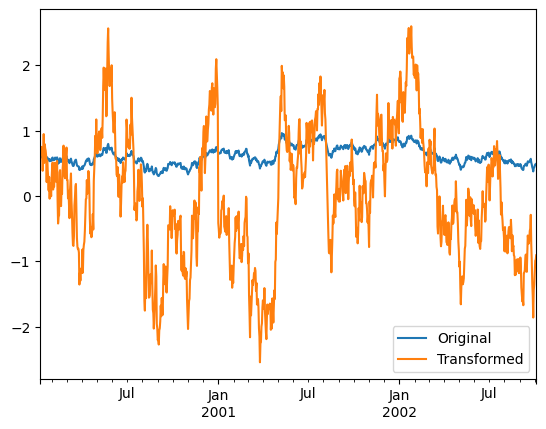

In [77]:
compare = pd.DataFrame(
    {
        "Original": ts,
        "Transformed": transformed,
    }
)
compare.plot()

In [78]:
ts.groupby(lambda x: x.year).transform(lambda x: x.max() - x.min())

2000-01-08    0.491088
2000-01-09    0.491088
2000-01-10    0.491088
2000-01-11    0.491088
2000-01-12    0.491088
                ...   
2002-09-30    0.546946
2002-10-01    0.546946
2002-10-02    0.546946
2002-10-03    0.546946
2002-10-04    0.546946
Freq: D, Length: 1001, dtype: float64

In [79]:
# Transform: replace missing data with group mean
cols = ["A", "B", "C"]
values = np.random.randn(1000, 3)
values[np.random.randint(0, 1000, 100), 0] = np.nan
values[np.random.randint(0, 1000, 50), 1] = np.nan
values[np.random.randint(0, 1000, 200), 2] = np.nan
data_df = pd.DataFrame(values, columns=cols)
data_df

,A,B,C
0,NaN,-0.009962,0.330609
1,NaN,NaN,0.448703
2,-0.709540,0.106600,0.562053
3,0.993251,0.146522,-1.297256
4,0.596044,1.314750,0.580563
...,...,...,...
995,2.158642,-0.918740,-0.436524
996,0.162615,0.820544,-1.472661
997,-0.144483,-1.769889,-0.689898
998,0.981506,-1.696748,1.765583


In [80]:
countries = np.array(["US", "UK", "GR", "JP"])
key = countries[np.random.randint(0, 4, 1000)]
grouped = data_df.groupby(key)

# Non-NA count in each group
grouped.count()

,A,B,C
GR,233,254,225
JP,203,212,180
UK,225,242,212
US,241,243,204


In [81]:
transformed = grouped.transform(lambda x: x.fillna(x.mean()))

In [82]:
grouped_trans = transformed.groupby(key)
grouped.mean()  # original group means

,A,B,C
GR,-0.000447,-0.120612,-0.059209
JP,-0.042042,-0.144975,0.010902
UK,-0.014857,0.056926,-0.085561
US,0.000951,0.006867,0.041575


In [83]:
grouped_trans.mean()  # transformation didn't change group means

,A,B,C
GR,-0.000447,-0.120612,-0.059209
JP,-0.042042,-0.144975,0.010902
UK,-0.014857,0.056926,-0.085561
US,0.000951,0.006867,0.041575


In [84]:
grouped.count()  # original has some missing data points

,A,B,C
GR,233,254,225
JP,203,212,180
UK,225,242,212
US,241,243,204


In [85]:
grouped_trans.count()  # counts after transformation

,A,B,C
GR,269,269,269
JP,227,227,227
UK,249,249,249
US,255,255,255


In [86]:
grouped_trans.size()  # verify non-NA count equals group size

GR    269
JP    227
UK    249
US    255
dtype: int64

In [87]:
# For more efficient computations use built-in methods and NOT udfs
grouped = ts.groupby(lambda x: x.year)
result = (ts - grouped.transform("mean")) / grouped.transform("std")
grouped = ts.groupby(lambda x: x.year)
result = grouped.transform("max") - grouped.transform("min")
grouped = data_df.groupby(key)
result = data_df.fillna(grouped.transform("mean"))

## Window and Resample Operations

**DataFrameGroupBy.rolling(window)**<br/>
Returns a rolling grouper, providing rolling functionality per group.
- window : interval of the rolling window

In [88]:
df_re = pd.DataFrame(
    {
        "A": [1] * 10 + [5] * 10,
        "B": np.arange(20),
    }
)
df_re

,A,B
0,1,0
1,1,1
2,1,2
3,1,3
4,1,4
5,1,5
6,1,6
7,1,7
8,1,8
9,1,9


In [89]:
df_re.groupby("A").rolling(4).B.mean()

A    
1  0      NaN
   1      NaN
   2      NaN
   3      1.5
   4      2.5
   5      3.5
   6      4.5
   7      5.5
   8      6.5
   9      7.5
5  10     NaN
   11     NaN
   12     NaN
   13    11.5
   14    12.5
   15    13.5
   16    14.5
   17    15.5
   18    16.5
   19    17.5
Name: B, dtype: float64

In [90]:
df_re.groupby("A").expanding().sum()

B
A          
1 0     0.0
  1     1.0
  2     3.0
  3     6.0
  4    10.0
  5    15.0
  6    21.0
  7    28.0
  8    36.0
  9    45.0
5 10   10.0
  11   21.0
  12   33.0
  13   46.0
  14   60.0
  15   75.0
  16   91.0
  17  108.0
  18  126.0
  19  145.0

# Filtration

In [91]:
# Return the nth row (starting from index 0) from each group
speeds.groupby("class").nth(1)

,class,order,max_speed
parrot,bird,Psittaciformes,24.0
monkey,mammal,Primates,NaN


In [92]:
speeds.groupby("class")[["order", "max_speed"]].nth(1)

,order,max_speed
parrot,Psittaciformes,24.0
monkey,Primates,NaN


## Built-in Filtrations

<dl>
    <dt style='font-weight:bold;color:green;'>head()</dt>
    <dd>Select the top rows of each group</dd>
    <dt style='font-weight:bold;color:green;'>nth()</dt>
    <dd>Select the nth row of each group</dd>
    <dt style='font-weight:bold;color:green;'>tail()</dt>
    <dd>Select the bottom rows of each group</dd>
</dl>


In [93]:
# The following table contains products (each belonging to a specific group)
# and their volumes.
# OBJECTIVE: Get a subset of the data with only the largest products
#            totalling no more than 90% of each group's volume.
product_volumes = pd.DataFrame(
    {
        "group": list("xxxxyyy"),
        "product": list("abcdefg"),
        "volume": [10, 30, 20, 15, 40, 10, 20],
    }
)
product_volumes

,group,product,volume
0,x,a,10
1,x,b,30
2,x,c,20
3,x,d,15
4,y,e,40
5,y,f,10
6,y,g,20


In [94]:
# First, sort by volume to select the largest products first
product_volumes.sort_values("volume", ascending=False, inplace=True)

In [95]:
product_volumes

,group,product,volume
4,y,e,40
1,x,b,30
2,x,c,20
6,y,g,20
3,x,d,15
0,x,a,10
5,y,f,10


In [96]:
grouped = product_volumes.groupby("group")["volume"]

In [97]:
cumpct = grouped.cumsum() / grouped.transform("sum")

In [98]:
# Note that the order of the indices in cumpct, is the same as the order in product_volumes
cumpct

4    0.571429
1    0.400000
2    0.666667
6    0.857143
3    0.866667
0    1.000000
5    1.000000
Name: volume, dtype: float64

In [99]:
significant_products = product_volumes[cumpct <= 0.9]
significant_products

,group,product,volume
4,y,e,40
1,x,b,30
2,x,c,20
6,y,g,20
3,x,d,15


In [100]:
significant_products.sort_values(["group", "product"])

,group,product,volume
1,x,b,30
2,x,c,20
3,x,d,15
4,y,e,40
6,y,g,20


## The `filter` Method

In [101]:
# OBJECTIVE: take only elements belonging to groups with a group sum > 2:
sf = pd.Series([1, 1, 2, 3, 3, 3])
sf.groupby(sf).filter(lambda x: x.sum() > 2)

3    3
4    3
5    3
dtype: int64

In [102]:
dff = pd.DataFrame(
    {
        "A": np.arange(8),
        "B": list("aabbbbcc"),
    }
)
dff.groupby("B").filter(lambda x: len(x) > 2)

,A,B
2,2,b
3,3,b
4,4,b
5,5,b


In [103]:
# Instead of dropping, fill the groups that do not pass the test with NaNs
dff.groupby("B").filter(lambda x: len(x) > 2, dropna=False)

,A,B
0,NaN,NaN
1,NaN,NaN
2,2.0,b
3,3.0,b
4,4.0,b
5,5.0,b
6,NaN,NaN
7,NaN,NaN


# Flexible `apply`

In [104]:
df

,A,B,C,D
0,foo,one,-0.131856,-0.498288
1,bar,one,-1.231004,-0.290932
2,foo,two,-0.647966,-0.411487
3,bar,three,-1.364391,1.256984
4,foo,two,1.689970,1.068903
5,bar,two,-0.493866,1.551329
6,foo,one,1.414405,0.512014
7,foo,three,-1.096674,0.333688


In [105]:
grouped = df.groupby("A")

# Could also just call describe()
grouped["C"].apply(lambda x: x.describe())

A         
bar  count    3.000000
     mean    -1.029754
     std      0.468860
     min     -1.364391
     25%     -1.297697
     50%     -1.231004
     75%     -0.862435
     max     -0.493866
foo  count    5.000000
     mean     0.245576
     std      1.244482
     min     -1.096674
     25%     -0.647966
     50%     -0.131856
     75%      1.414405
     max      1.689970
Name: C, dtype: float64

In [106]:
# Change the dimension of the returned result:
grouped = df.groupby("A")["C"]


def f(group):
    return pd.DataFrame(
        {
            "original": group,
            "demeaned": group - group.mean(),
        }
    )


grouped.apply(f)

original  demeaned
A                        
bar 1 -1.231004 -0.201250
    3 -1.364391 -0.334638
    5 -0.493866  0.535888
foo 0 -0.131856 -0.377432
    2 -0.647966 -0.893542
    4  1.689970  1.444394
    6  1.414405  1.168830
    7 -1.096674 -1.342250

In [107]:
def f(x):
    return pd.Series([x, x**2], index=["x", "x^2"])


s = pd.Series(np.random.rand(5))
s

0    0.691670
1    0.213935
2    0.131303
3    0.660720
4    0.990290
dtype: float64

In [108]:
# Here, the result is upcast to a DataFrame
s.apply(f)

,x,x^2
0,0.691670,0.478408
1,0.213935,0.045768
2,0.131303,0.017240
3,0.660720,0.436551
4,0.990290,0.980674


## Control grouped column(s) placement with `group_keys`

In [109]:
# Include grouped columns in the index
df.groupby("A", group_keys=True).apply(lambda x: x)

B         C         D
A                               
bar 1    one -1.231004 -0.290932
    3  three -1.364391  1.256984
    5    two -0.493866  1.551329
foo 0    one -0.131856 -0.498288
    2    two -0.647966 -0.411487
    4    two  1.689970  1.068903
    6    one  1.414405  0.512014
    7  three -1.096674  0.333688

In [110]:
# Exclude grouped columns in the index
df.groupby("A", group_keys=False).apply(lambda x: x)

,B,C,D
0,one,-0.131856,-0.498288
1,one,-1.231004,-0.290932
2,two,-0.647966,-0.411487
3,three,-1.364391,1.256984
4,two,1.689970,1.068903
5,two,-0.493866,1.551329
6,one,1.414405,0.512014
7,three,-1.096674,0.333688


# Other Useful Features
## Exclusion of Non-Numeric Columns

In [111]:
# Calculate STD grouped by column A:
# Remember to EXCLUDE column B since it's not numeric
df.groupby("A").std(numeric_only=True)

,C,D
A,,
bar,0.468860,0.989664
foo,1.244482,0.657977


In [112]:
# If onlly the result for one column is neede, don't perform aggregation
# on the whole dataset and then index the column; instead, first index
# and then aggregate:
from decimal import Decimal

df_dec = pd.DataFrame(
    {
        "id": [1, 2, 1, 2],
        "int_column": [1, 2, 3, 4],
        "dec_column": [
            Decimal("0.50"),
            Decimal("0.15"),
            Decimal("0.25"),
            Decimal("0.40"),
        ],
    }
)
df_dec

,id,int_column,dec_column
0,1,1,0.50
1,2,2,0.15
2,1,3,0.25
3,2,4,0.40


In [113]:
df_dec.groupby("id")["dec_column"].sum()

id
1    0.75
2    0.55
Name: dec_column, dtype: object

## Handling of (un)observed Categorical values

In [114]:
pd.Series([1, 1, 1]).groupby(
    pd.Categorical(["a", "a", "a"], categories=["a", "b"]),
    observed=False,
).count()

a    3
b    0
dtype: int64

The above shows ALL values : 3 a's and no b's.<br/>
Below we show only the observed categorical values i.e. "a" only, and not all allowed values ("a", "b")

In [115]:
pd.Series([1, 1, 1]).groupby(
    pd.Categorical(["a", "a", "a"], categories=["a", "b"]),
    observed=True,
).count()

a    3
dtype: int64

In [116]:
s = (
    pd.Series([1, 1, 1])
    .groupby(
        pd.Categorical(["a", "a", "a"], categories=["a", "b"]),
        observed=True,
    )
    .count()
)

s.index.dtype

CategoricalDtype(categories=['a', 'b'], ordered=False, categories_dtype=str)

## NA Group Handling

In [117]:
# Group keys that are NA (NA, NaN, NaT, None) are excluded from the results by default.
# To include NA group keys, specify dropna=False
df = pd.DataFrame({"key": [1.0, 1.0, np.nan, 2.0, np.nan], "A": [1, 2, 3, 4, 5]})
df

,key,A
0,1.0,1
1,1.0,2
2,NaN,3
3,2.0,4
4,NaN,5


In [118]:
df.groupby("key", dropna=True).sum()

,A
key,
1.0,3
2.0,4


In [119]:
df.groupby("key", dropna=False).sum()

,A
key,
1.0,3
2.0,4
NaN,8


## Grouping with Ordered Factors

In [120]:
days = pd.Categorical(
    values=["Wed", "Mon", "Thu", "Mon", "Wed", "Sat"],
    categories=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
)

data = pd.DataFrame(
    {
        "day": days,
        "workers": [3, 4, 1, 4, 2, 2],
    }
)

data

,day,workers
0,Wed,3
1,Mon,4
2,Thu,1
3,Mon,4
4,Wed,2
5,Sat,2


In [121]:
# observed=False, means include also the unobserved categories of Tue, Fri, and Sun in the results
data.groupby("day", observed=False, sort=True).sum()

,workers
day,
Mon,8
Tue,0
Wed,5
Thu,1
Fri,0
Sat,2
Sun,0


## Grouping with a grouper specification

In [122]:
from datetime import datetime

df = pd.DataFrame(
    {
        "Branch": "A A A A A A A B".split(),
        "Buyer": "Carl Mark Carl Carl Joe Joe Joe Carl".split(),
        "Quantity": [1, 3, 5, 1, 8, 1, 9, 3],
        "Date": [
            datetime(2013, 1, 1, 13, 0),
            datetime(2013, 1, 1, 13, 5),
            datetime(2013, 10, 1, 20, 0),
            datetime(2013, 10, 2, 10, 0),
            datetime(2013, 10, 1, 20, 0),
            datetime(2013, 10, 2, 10, 0),
            datetime(2013, 12, 2, 12, 0),
            datetime(2013, 12, 2, 14, 0),
        ],
    }
)

In [123]:
df

,Branch,Buyer,Quantity,Date
0,A,Carl,1,2013-01-01 13:00:00
1,A,Mark,3,2013-01-01 13:05:00
2,A,Carl,5,2013-10-01 20:00:00
3,A,Carl,1,2013-10-02 10:00:00
4,A,Joe,8,2013-10-01 20:00:00
5,A,Joe,1,2013-10-02 10:00:00
6,A,Joe,9,2013-12-02 12:00:00
7,B,Carl,3,2013-12-02 14:00:00


Group by a specific column with the desired frequency; like resampling.<br/>
Here we groupby month's end and then by buyer:

In [124]:
df.groupby([pd.Grouper(freq="W", key="Date"), "Buyer"])[["Quantity"]].sum()

Quantity
Date       Buyer          
2013-01-06 Carl          1
           Mark          3
2013-10-06 Carl          6
           Joe           9
2013-12-08 Carl          3
           Joe           9

When a column and index have the same name, use "key" to group by the column and "level" to group by the index.

In [125]:
# Use an existing column "Date", as the new index.
# This removes "Date" from column.
df = df.set_index("Date")
df

,Branch,Buyer,Quantity
Date,,,
2013-01-01 13:00:00,A,Carl,1
2013-01-01 13:05:00,A,Mark,3
2013-10-01 20:00:00,A,Carl,5
2013-10-02 10:00:00,A,Carl,1
2013-10-01 20:00:00,A,Joe,8
2013-10-02 10:00:00,A,Joe,1
2013-12-02 12:00:00,A,Joe,9
2013-12-02 14:00:00,B,Carl,3


In [126]:
# Define a new "Date" column, from the index, offset by two mont-ends
# e.g 2013-01-01 -> 2013-02-28
df["Date"] = df.index + pd.offsets.MonthEnd(2)
df

,Branch,Buyer,Quantity,Date
Date,,,,
2013-01-01 13:00:00,A,Carl,1,2013-02-28 13:00:00
2013-01-01 13:05:00,A,Mark,3,2013-02-28 13:05:00
2013-10-01 20:00:00,A,Carl,5,2013-11-30 20:00:00
2013-10-02 10:00:00,A,Carl,1,2013-11-30 10:00:00
2013-10-01 20:00:00,A,Joe,8,2013-11-30 20:00:00
2013-10-02 10:00:00,A,Joe,1,2013-11-30 10:00:00
2013-12-02 12:00:00,A,Joe,9,2014-01-31 12:00:00
2013-12-02 14:00:00,B,Carl,3,2014-01-31 14:00:00


In [127]:
df.groupby([pd.Grouper(freq="6ME", key="Date"), "Buyer"])["Quantity"].sum()

Date        Buyer
2013-02-28  Carl      1
            Mark      3
2014-02-28  Carl      9
            Joe      18
Name: Quantity, dtype: int64

In [128]:
df.groupby([pd.Grouper(freq="6ME", level="Date"), "Buyer"])["Quantity"].sum()

Date        Buyer
2013-01-31  Carl      1
            Mark      3
2014-01-31  Carl      9
            Joe      18
Name: Quantity, dtype: int64

## Taking the first rows of each group

In [129]:
df = pd.DataFrame([[1, 2], [1, 4], [5, 6]], columns=["A", "B"])
g = df.groupby("A")
g.head(1)  # return 1st row of each group

,A,B
0,1,2
2,5,6


In [130]:
g.tail(1)

,A,B
1,1,4
2,5,6


## Taking the nth row of each group

In [131]:
df = pd.DataFrame([[1, np.nan], [1, 4], [5, 6]], columns=["A", "B"])
df

,A,B
0,1,NaN
1,1,4.0
2,5,6.0


In [132]:
g = df.groupby("A")
g.nth(0)

,A,B
0,1,NaN
2,5,6.0


In [133]:
g.nth(-1)

,A,B
1,1,4.0
2,5,6.0


## Enumerate Group Items

In [134]:
dfg = pd.DataFrame(list("aaabba"), columns=["A"])
dfg

,A
0,a
1,a
2,a
3,b
4,b
5,a


In [135]:
# Number each item in each group ("a" and "b")
dfg.groupby("A").cumcount()

0    0
1    1
2    2
3    0
4    1
5    3
dtype: int64

## Enumerate Groups

In [136]:
dfg = pd.DataFrame(list("aaabba"), columns=["A"])
dfg

,A
0,a
1,a
2,a
3,b
4,b
5,a


In [137]:
dfg.groupby("A").ngroup(ascending=False)

0    1
1    1
2    1
3    0
4    0
5    1
dtype: int64

## Plotting

In [138]:
np.random.seed(1234)
df = pd.DataFrame(np.random.randn(50, 2))
df["g"] = np.random.choice(["A", "B"], size=50)
df.head(7)

,0,1,g
0,0.471435,-1.190976,A
1,1.432707,-0.312652,A
2,-0.720589,0.887163,B
3,0.859588,-0.636524,A
4,0.015696,-2.242685,B
5,1.150036,0.991946,A
6,0.953324,-2.021255,A


In [139]:
df.loc[df["g"] == "B", 1] += 3
df.head(7)

,0,1,g
0,0.471435,-1.190976,A
1,1.432707,-0.312652,A
2,-0.720589,3.887163,B
3,0.859588,-0.636524,A
4,0.015696,0.757315,B
5,1.150036,0.991946,A
6,0.953324,-2.021255,A


A         Axes(0.1,0.15;0.363636x0.75)
B    Axes(0.536364,0.15;0.363636x0.75)
dtype: object

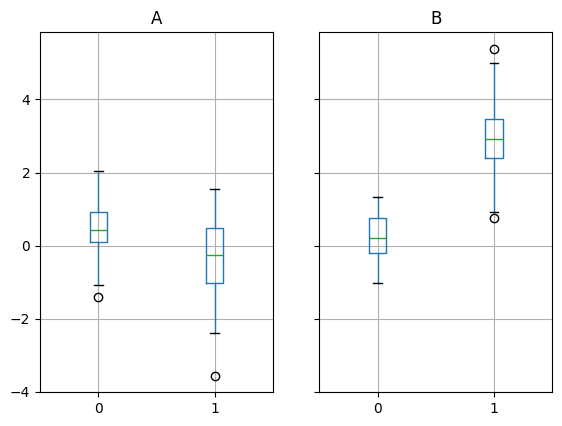

In [140]:
df.groupby("g").boxplot()

## Piping Function Calls

Chain together function calls that are applied to GroupBy objects. This is useful when we need to reuse GroupBy objects.

In [141]:
# A DataFrame with info about stores, products, revenue and quantity
# sold
n = 1000

df = pd.DataFrame(
    {
        "Store": np.random.choice(["Store_1", "Store_2"], n),
        "Product": np.random.choice(["Product_1", "Product_2"], n),
        "Revenue": (np.random.random(n) * 50 + 10).round(2),
        "Quantity": np.random.randint(1, 10, size=n),
    }
)

df.head(7)

,Store,Product,Revenue,Quantity
0,Store_2,Product_1,26.12,1
1,Store_2,Product_1,28.86,1
2,Store_2,Product_1,35.11,9
3,Store_1,Product_1,32.50,1
4,Store_1,Product_2,33.37,1
5,Store_2,Product_1,15.24,5
6,Store_1,Product_1,28.69,8


In [142]:
# fmt: off
#
# Make a groupwise calculation of prices (revenue/quantity)
# per store and per product:
(
    df.groupby(["Store", "Product"])
    .pipe(lambda grp: grp.Revenue.sum() / grp.Quantity.sum())
    .unstack()
    .round(2))

Product,Product_1,Product_2
Store,,
Store_1,6.82,7.05
Store_2,6.30,6.64


In [143]:
def mean(groupby):
    return groupby.mean()


df.groupby(["Store", "Product"]).pipe(mean)

Revenue  Quantity
Store   Product                       
Store_1 Product_1  34.622727  5.075758
        Product_2  35.482815  5.029630
Store_2 Product_1  32.972837  5.237589
        Product_2  34.684360  5.224000